# 01 - Exploratory data analysis

This notebook contains **no model logic**. It only describes `data/GOOGL.csv`, the
single source of truth for the project, and writes the exploratory figures into
`figures/`. The modelling walkthrough is `02_lstm_walkthrough.ipynb`.

Every cell here runs top to bottom from a fresh kernel: the state a cell depends on
is created by an earlier cell in this same file, never by an earlier execution of a
different cell.

## 0. Setup

Make the project root importable so the notebook can use the same `src/` package the
pipeline uses - no logic is redefined here.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config, plots
from src.data_loader import load_prices
from src.preprocessing import to_log_returns

config.ensure_directories()
print(f'project root : {PROJECT_ROOT}')
print(f'data file    : {config.DATA_PATH}')
print(f'figures      : {config.FIGURES_DIR}')

project root : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM
data file    : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM\data\GOOGL.csv
figures      : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM\figures


## 1. Load and validate

`load_prices` parses `Date`, sorts oldest first and refuses to return anything with a
missing column, a null, a non-positive price or a duplicate date.

In [2]:
prices = load_prices(config.DATA_PATH, config.TARGET_COLUMN)

print(prices.describe())
print(f'rows              : {prices.size}')
print(f'first date        : {prices.dates.iloc[0].date()}')
print(f'last date         : {prices.dates.iloc[-1].date()}')
print(f'chronological     : {prices.dates.is_monotonic_increasing}')
print(f'null prices       : {int(prices.frame[config.TARGET_COLUMN].isna().sum())}')
print(f'duplicate dates   : {int(prices.dates.duplicated().sum())}')

Close: 4431 rows, 2004-08-19 -> 2022-03-24, min 50.06, max 2996.77
rows              : 4431
first date        : 2004-08-19
last date         : 2022-03-24
chronological     : True
null prices       : 0
duplicate dates   : 0


## 2. What the raw file actually contains

`GOOGL.csv` ships more columns than the model uses. Showing them all here makes the
gap between "what is available" and "what is modelled" explicit.

In [3]:
raw = pd.read_csv(config.DATA_PATH)

print(f'columns : {list(raw.columns)}')
print(f'shape   : {raw.shape}')
raw.isna().sum().rename('nulls')

columns : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
shape   : (4431, 7)


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Name: nulls, dtype: int64

In [4]:
raw.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602


In [5]:
raw.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4426,2022-03-18,2668.489990,2724.879883,2645.169922,2722.510010,2722.510010,2223100
4427,2022-03-21,2723.270020,2741.000000,2681.850098,2722.030029,2722.030029,1341600
4428,2022-03-22,2722.030029,2821.000000,2722.030029,2797.360107,2797.360107,1774800
4429,2022-03-23,2774.050049,2791.770020,2756.699951,2765.510010,2765.510010,1257700
4430,2022-03-24,2784.000000,2832.379883,2755.010010,2831.439941,2831.439941,1317900


## 3. Closing price over the full history

The target column is `Close`, fixed once in `src/config.py`. The original notebook
titled its plots "Close" and then trained on `Open`; that mismatch is why one
constant now controls the column everywhere.

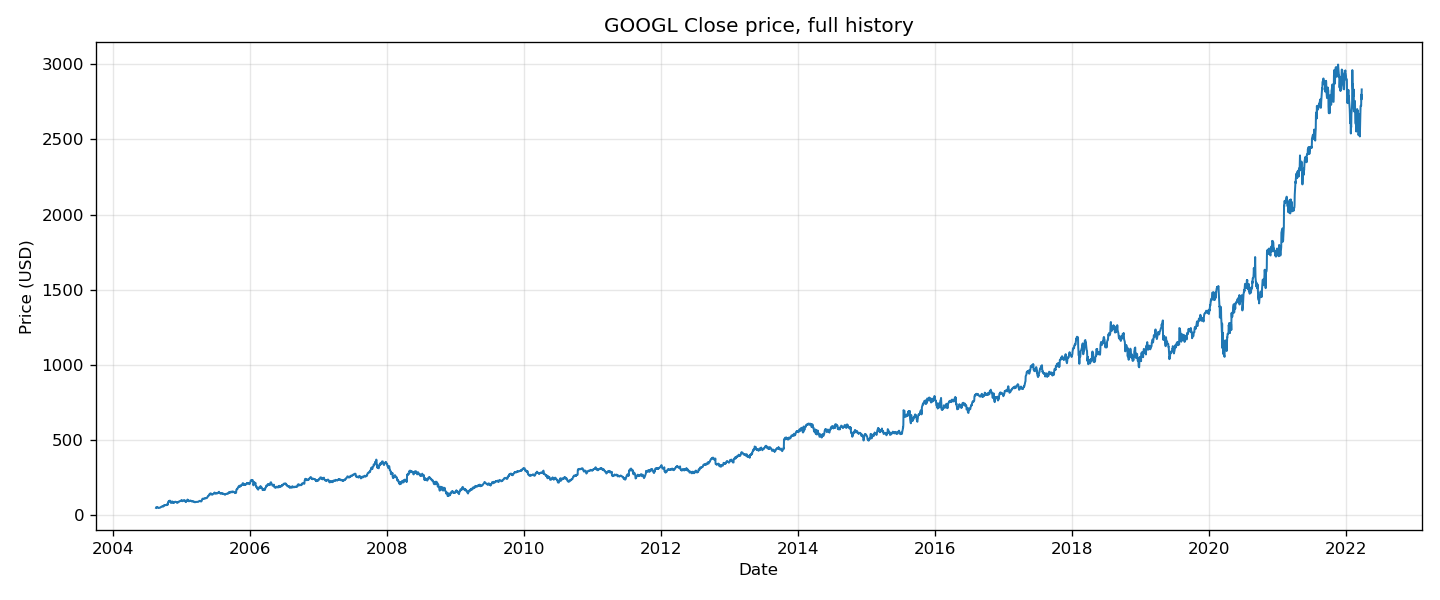

In [6]:
price_history_png = config.FIGURES_DIR / 'price_history.png'
plots.plot_price_history(
    prices.dates, prices.values, price_history_png, prices.column
)
display(Image(filename=str(price_history_png)))

## 4. Price with its long moving averages

The original notebook computed a 233-day and a 100-day moving average and a percent
change column, plotted them, and then never fed any of them to the model. They are
kept as description only.

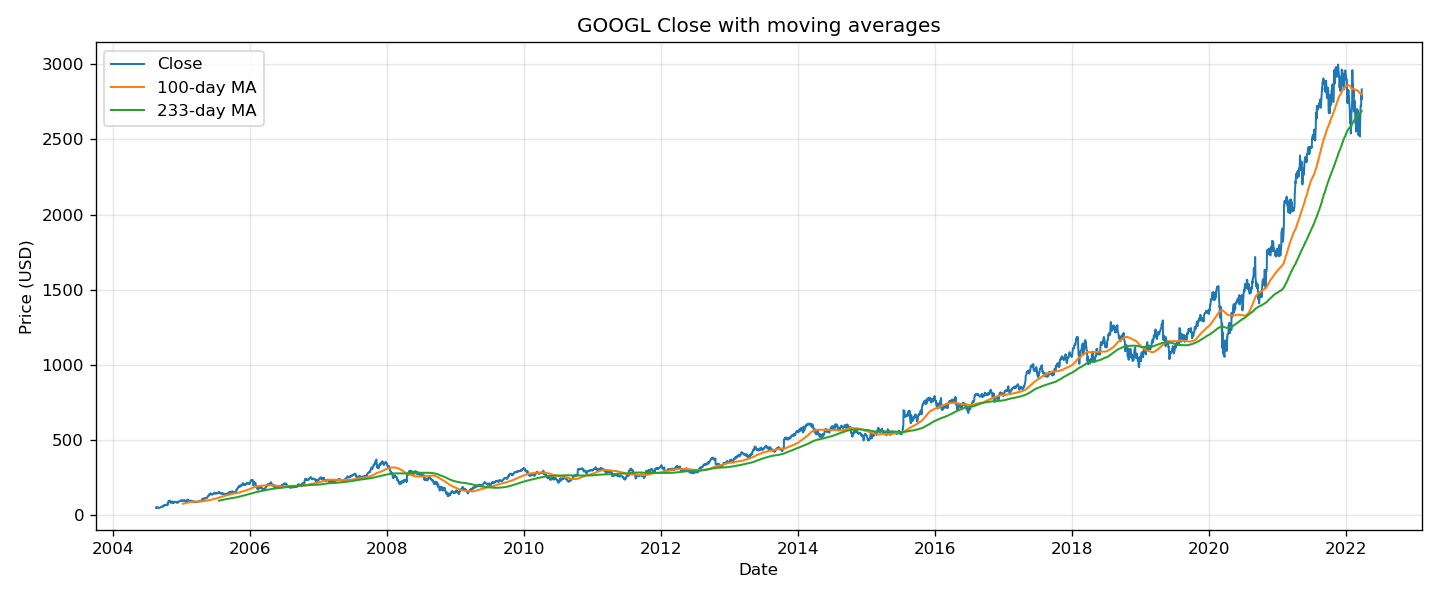

In [7]:
moving_average_png = config.FIGURES_DIR / 'price_moving_averages.png'
plots.plot_price_with_moving_averages(
    prices.dates, prices.values, moving_average_png, prices.column
)
display(Image(filename=str(moving_average_png)))

In [8]:
indicators = prices.frame.copy()
for window in plots.MOVING_AVERAGE_WINDOWS:
    indicators[f'MA_{window}'] = indicators[config.TARGET_COLUMN].rolling(window).mean()
indicators['pct_change'] = indicators[config.TARGET_COLUMN].pct_change() * 100.0

indicators.tail()

,Date,Close,MA_100,MA_233,pct_change
4426,2022-03-18,2722.510010,2802.691404,2679.136570,1.708395
4427,2022-03-21,2722.030029,2802.050005,2680.991806,-0.017630
4428,2022-03-22,2797.360107,2800.780105,2683.216485,2.767423
4429,2022-03-23,2765.510010,2799.265405,2685.307300,-1.138577
4430,2022-03-24,2831.439941,2797.970605,2687.791935,2.384006


## 5. Trading volume

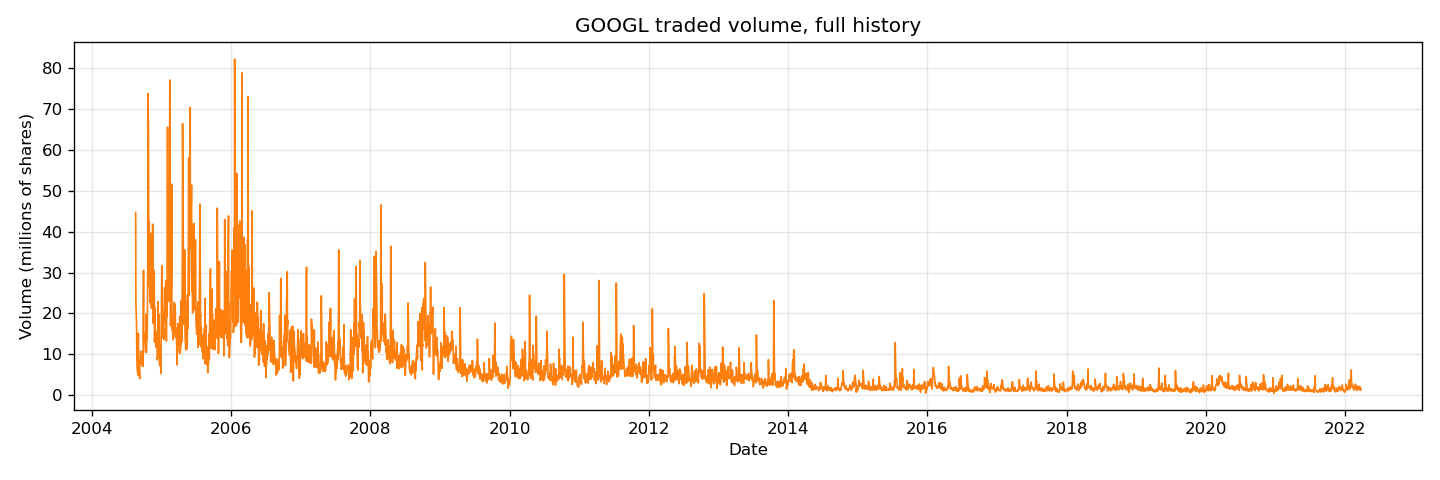

In [9]:
volume_png = config.FIGURES_DIR / 'volume_history.png'
plots.plot_volume_history(
    prices.dates,
    raw['Volume'].to_numpy(dtype=float),
    volume_png,
    'GOOGL traded volume, full history',
)
display(Image(filename=str(volume_png)))

In [10]:
volume_by_year = (
    raw.assign(year=pd.to_datetime(raw['Date']).dt.year)
    .groupby('year')['Volume']
    .mean()
    .div(1e6)
    .round(2)
)

volume_by_year.tail(10)

year
2013    4.17
2014    2.67
2015    2.17
2016    1.97
2017    1.62
2018    2.05
2019    1.51
2020    2.00
2021    1.53
2022    1.99
Name: Volume, dtype: float64

## 6. Daily log returns

Returns are the third prediction target used by the pipeline. Unlike the price
level, they are close to stationary - there is no trend to copy, which is exactly
why they make a more honest test of a model.

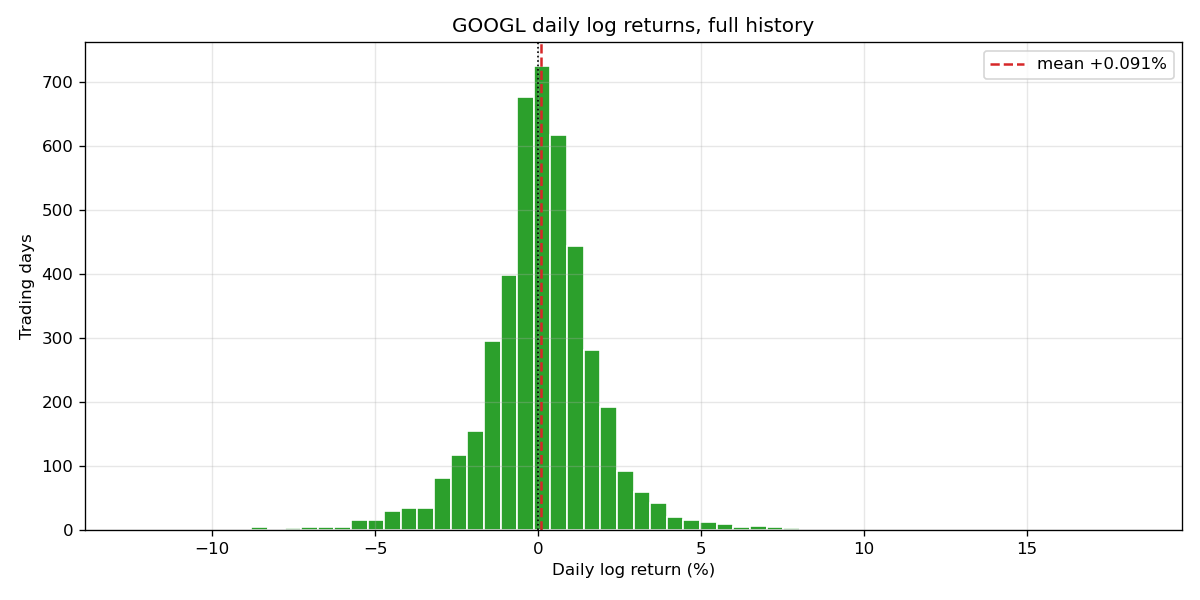

In [11]:
returns_png = config.FIGURES_DIR / 'return_distribution.png'
all_returns = to_log_returns(prices.values)
plots.plot_return_distribution(
    all_returns, returns_png, 'GOOGL daily log returns, full history'
)
display(Image(filename=str(returns_png)))

In [12]:
returns_frame = pd.DataFrame(
    {'Date': prices.dates.iloc[1:].to_numpy(), 'log_return': all_returns}
)
returns_frame['year'] = pd.to_datetime(returns_frame['Date']).dt.year

annual = returns_frame.groupby('year')['log_return'].agg(['count', 'mean', 'std'])
annual['mean'] = annual['mean'] * 100.0
annual['std'] = annual['std'] * 100.0
annual.rename(columns={'count': 'days', 'mean': 'mean %', 'std': 'daily vol %'}).round(3).tail(10)

,days,mean %,daily vol %
year,,,
2013,252,0.183,1.342
2014,252,-0.022,1.343
2015,252,0.152,1.771
2016,252,0.007,1.272
2017,251,0.113,0.962
2018,251,-0.003,1.783
2019,252,0.099,1.490
2020,253,0.106,2.432
2021,252,0.199,1.525


## 7. What the split will look like

The pipeline cuts the timeline once, chronologically: the most recent 10% becomes the
test set and everything before it is training. Confirming the boundary here makes the
later numbers readable.

In [13]:
from src.preprocessing import chronological_split

split = chronological_split(prices.frame, config.TEST_FRACTION)

print(
    f'train : {split.train_frame["Date"].iloc[0].date()} -> '
    f'{split.train_frame["Date"].iloc[-1].date()}  ({split.train_size} rows)'
)
print(
    f'test  : {split.test_frame["Date"].iloc[0].date()} -> '
    f'{split.test_frame["Date"].iloc[-1].date()}  ({split.test_size} rows)'
)
print(f'overlap between the two slices: {len(set(split.train_frame["Date"]) & set(split.test_frame["Date"]))}')
print()
print(
    'train price range:',
    f'{split.train_frame[config.TARGET_COLUMN].min():.2f}',
'-',
    f'{split.train_frame[config.TARGET_COLUMN].max():.2f}',
)
print(
    'test  price range:',
    f'{split.test_frame[config.TARGET_COLUMN].min():.2f}',
'-',
    f'{split.test_frame[config.TARGET_COLUMN].max():.2f}',
)

train : 2004-08-19 -> 2020-06-19  (3987 rows)
test  : 2020-06-22 -> 2022-03-24  (444 rows)
overlap between the two slices: 0

train price range: 50.06 - 1524.87
test  price range: 1362.54 - 2996.77


## 8. Summary

- `data/GOOGL.csv` is already chronological; the loader only enforces that.
- The series is split 90/10 **by position**, never by shuffling.
- The test period sits outside the training price range, so a scaler fitted on train
  alone will see test values above 1.0. That is a real forecasting condition and the
  pipeline reports how many values are affected, and by how far, rather than
  clipping them.
- The pipeline trains three targets against that baseline. The price level is
  dominated by autocorrelation, so it is the hardest of the three to justify; the
  price change and the log return are stationary and are the honest scoreboards.